# BNPL Classification: Feature Selection + SVM

**Goals:**
- **BNPL-1**: Predict whether a respondent used BNPL
- **BNPL-3**: Predict whether a BNPL user was late on a BNPL payment

**Approach:** RFECV (recursive backward elimination via LinearSVC) selects features, then an RBF SVM classifies.  
Train/test split is done **before** feature selection to prevent data leakage.

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/data_merged.csv', low_memory=False)
# Drop BNPL sub-questions (perfectly correlated with BNPL1), temporal ID, and survey weight
drop_cols = ['BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year', 'weight']
df = df.drop(columns=drop_cols)

# One-hot encode all remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (47236, 89)


,Unnamed: 0,ppage,pphhsize,ppkid017,BNPL1_Yes,BNPL3_Yes,EF3_a_Yes,EF3_b_Yes,EF3_c_Yes,EF3_d_Yes,...,X12_c_Not a concern,X12_d_Minor concern,X12_d_Not a concern,X12_e_Minor concern,X12_e_Not a concern,X12_f_Minor concern,X12_f_Not a concern,X12_g_Minor concern,X12_g_Not a concern,EF5C_Yes
0,0,54,4,2,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,56,4,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,76,1,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,3,69,2,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,62,8,1,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False


In [3]:
def run_pipeline(X, y, label, target_names):
    # Step 1: train/test split (before any fitting to prevent leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Step 2: impute + scale (fit on train only)
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_train_proc = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_proc  = scaler.transform(imputer.transform(X_test))

    # Step 3: RFECV feature selection (fit on train only)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    selector = RFECV(LinearSVC(max_iter=2000, dual=False), step=5, cv=cv, scoring='roc_auc', n_jobs=-1)
    selector.fit(X_train_proc, y_train)

    # Find elbow: fewest features within 1% of max CV score
    scores = selector.cv_results_['mean_test_score']
    max_score = scores.max()
    threshold = max_score * 0.99
    elbow_n = next(i + 1 for i, s in enumerate(scores) if s >= threshold)

    # Select top-ranked features up to the elbow count
    rankings = selector.ranking_
    top_mask = rankings <= elbow_n
    X_train_sel = X_train_proc[:, top_mask]
    X_test_sel  = X_test_proc[:, top_mask]
    selected    = X.columns[top_mask].tolist()
    print(f'[{label}] {len(selected)} features selected (elbow at {elbow_n}, RFECV auto: {selector.support_.sum()}):')
    print(selected)

    # Plot CV score vs number of features
    plt.figure()
    plt.plot(range(1, len(scores) + 1), scores, marker='o', markersize=3)
    plt.axvline(x=elbow_n, color='r', linestyle='--', label=f'Elbow: {elbow_n}')
    plt.axhline(y=threshold, color='gray', linestyle=':', alpha=0.5, label='99% of max')
    plt.xlabel('Number of features')
    plt.ylabel('CV ROC AUC')
    plt.title(f'RFECV - {label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Step 4: train LinearSVC on selected features
    svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, dual=False)
    svm.fit(X_train_sel, y_train)

    # Print feature importance (SVM coefficients sorted by magnitude)
    coef_df = pd.DataFrame({
        'Feature': selected,
        'Coefficient': svm.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(f'\n[{label}] Feature coefficients (sorted by |coef|):')
    print(coef_df.to_string(index=False))

    y_pred = svm.predict(X_test_sel)
    y_scores = svm.decision_function(X_test_sel)

    # Step 5: evaluate
    print(f'[{label}] Test ROC AUC: {roc_auc_score(y_test, y_scores):.4f}')
    print(classification_report(y_test, y_pred, target_names=target_names))

    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=target_names, ax=ax, cmap=plt.cm.Greens
    )
    ax.set_title(f'{label} - LinearSVC Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return selector, svm, selected

### BNPL-1: Did the respondent use BNPL?

[BNPL-1] 87 features selected (elbow at 6, RFECV auto: 87):
['Unnamed: 0', 'ppage', 'pphhsize', 'ppkid017', 'EF3_a_Yes', 'EF3_b_Yes', 'EF3_c_Yes', 'EF3_d_Yes', 'EF3_e_Yes', 'EF3_f_Yes', 'EF3_g_Yes', 'EF3_h_Yes', 'I20_More than your income', 'I20_The same as your income', 'ppfs0596_$100,000 - $249,999', 'ppfs0596_$250,000 - $499,999', 'ppfs0596_$50,000 - $99,999', 'ppfs0596_$500,000 - $999,999', 'ppfs0596_Not sure', 'ppfs0596_Under $50,000', 'ppeducat_High school graduate (high school diploma or the equivalent GED)', 'ppeducat_No high school diploma or GED', "ppeducat_Some college or Associate's degree", 'ppagecat_25-34', 'ppagecat_35-44', 'ppagecat_45-54', 'ppagecat_55-64', 'ppagecat_65-74', 'ppagecat_75+', 'ppethm_Black, Non-Hispanic', 'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic', 'ppethm_White, Non-Hispanic', 'ppgender_Male', 'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more', 'ppinc7_$25,000 to $49,999', 'ppinc7_$50,000 to $74,999', 'ppinc7_$75,000 to $99,999', 'ppinc7_Less

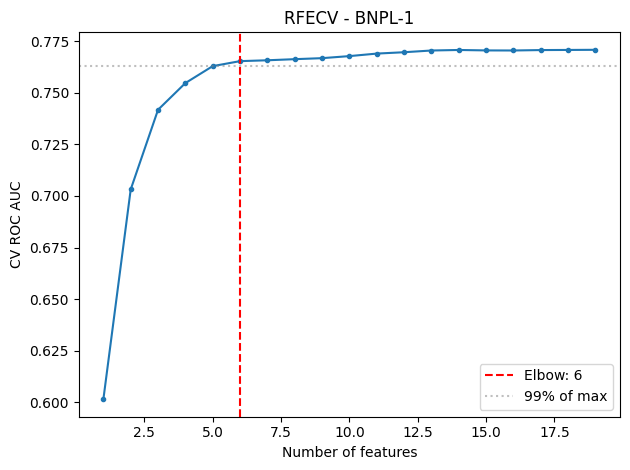


[BNPL-1] Feature coefficients (sorted by |coef|):
                                                                  Feature  Coefficient
                 C4A_Never carried an unpaid balance (always pay in full)    -0.149976
                                                                    ppage    -0.124012
                                                           ppagecat_65-74     0.102216
                                                        A6_Very confident     0.074809
                                                    A6_Somewhat confident     0.071688
                                                           ppagecat_55-64     0.069371
                                                                 A1_a_Yes     0.068896
                                                         A6_Not confident     0.063020
                                               ppemploy_Working full-time     0.061416
                                                            ppfs1482_Fair     0

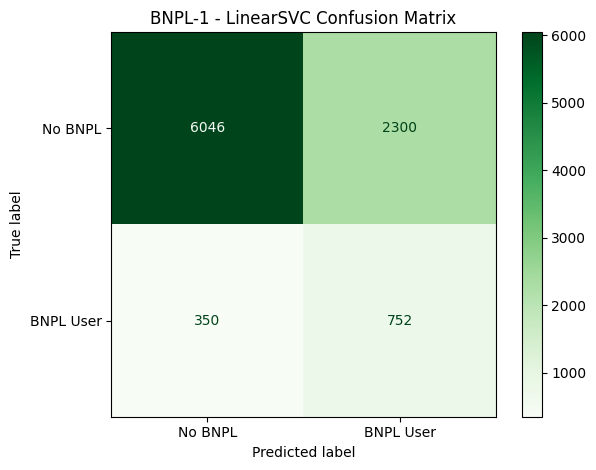

In [4]:
X1 = df.drop(columns=['BNPL1_Yes', 'BNPL3_Yes'])
y1 = df['BNPL1_Yes']

sel1, svm1, features1 = run_pipeline(
    X1, y1,
    label='BNPL-1',
    target_names=['No BNPL', 'BNPL User']
)

### BNPL-3: Was the respondent late on a BNPL payment?

Restricted to BNPL users only (BNPL-1 == 1). BNPL-3 == 1 means the user was late on at least one BNPL payment.

[BNPL-3] 62 features selected (elbow at 6, RFECV auto: 37):
['Unnamed: 0', 'pphhsize', 'ppkid017', 'EF3_a_Yes', 'EF3_b_Yes', 'EF3_c_Yes', 'EF3_f_Yes', 'EF3_h_Yes', 'I20_More than your income', 'I20_The same as your income', 'ppfs0596_$500,000 - $999,999', 'ppfs0596_Under $50,000', 'ppeducat_No high school diploma or GED', 'ppagecat_25-34', 'ppagecat_35-44', 'ppagecat_45-54', 'ppagecat_55-64', 'ppagecat_65-74', 'ppagecat_75+', 'ppethm_Black, Non-Hispanic', 'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic', 'ppethm_White, Non-Hispanic', 'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more', 'ppinc7_$25,000 to $49,999', 'ppinc7_$50,000 to $74,999', 'ppinc7_$75,000 to $99,999', 'ppmarit5_Never married', 'ppmarit5_Now married', 'ppfs1482_Good', 'ppfs1482_Poor', 'ppfs1482_Very poor', 'SL6_Yes', 'B3_Much better off', 'B3_Much worse off', 'A6_Not confident', 'A6_Somewhat confident', 'A6_Very confident', 'C4A_Never carried an unpaid balance (always pay in full)', 'C4A_Once', 'C4A_Some of the t

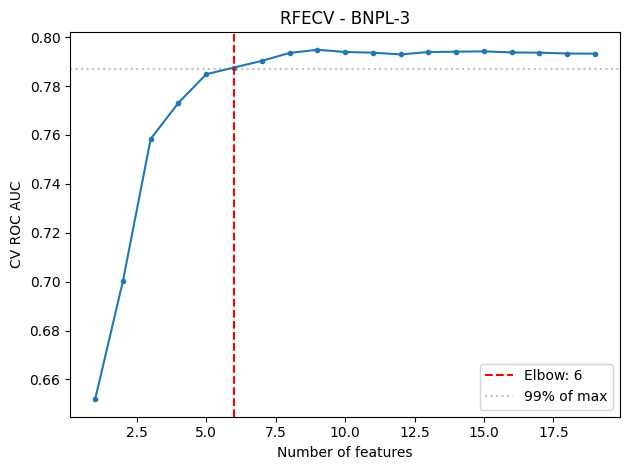


[BNPL-3] Feature coefficients (sorted by |coef|):
                                                 Feature  Coefficient
                                 ppinc7_$150,000 or more    -0.142180
                             ppinc7_$100,000 to $149,999    -0.134585
                                          ppagecat_65-74    -0.132270
                                       A6_Very confident    -0.126127
                               ppinc7_$75,000 to $99,999    -0.122182
                                                ppkid017    -0.118877
                                     X12_g_Minor concern     0.086143
                               ppinc7_$50,000 to $74,999    -0.079987
                                          ppagecat_55-64    -0.074460
                                           ppfs1482_Poor     0.073059
                               ppinc7_$25,000 to $49,999    -0.065798
                                               EF3_f_Yes     0.065780
                                       

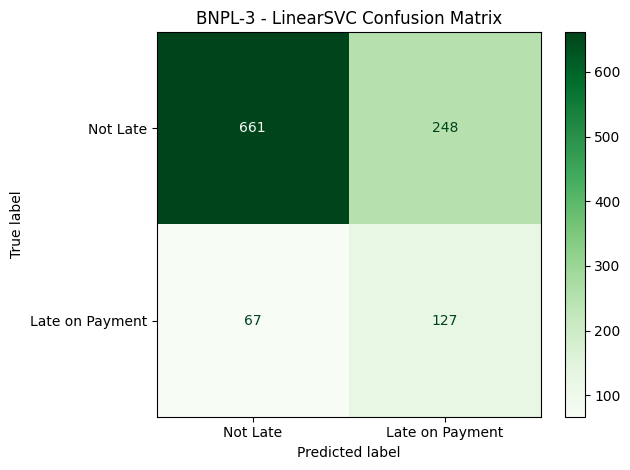

In [5]:
bnpl_users = df[df['BNPL1_Yes'] == 1].dropna(subset=['BNPL3_Yes'])

X3 = bnpl_users.drop(columns=['BNPL1_Yes', 'BNPL3_Yes'])
y3 = bnpl_users['BNPL3_Yes'].astype(int)

sel3, svm3, features3 = run_pipeline(
    X3, y3,
    label='BNPL-3',
    target_names=['Not Late', 'Late on Payment']
)

### Interpretation
In general, coefficients were quite small, which indicates that no single feature works as a strong predictor on its own. However, some larger themes emerge.

BNPL 1: The model reaches 99% of its optimal ROC-AUC score at 6 features selected. To generalize: 
>The largest predictors of being a non-adopter included old age (ppage), and never carrying an unpaid credit card balance. 

>Predictors of being an adopter included one's household spending being greater than or equal to household income. All answers to A6, which involves one's confidence that they would be able to be approved for a credit card application, were included in the final model as positive predictors.

BNPL 3: The model reaches 99% of its optimal ROC-AUC score at 6 features. 
>Among BNPL users, the model selected high income levels, confidence in applying for a credit card, and old age as predictors of not being late on a BNPL payment. 

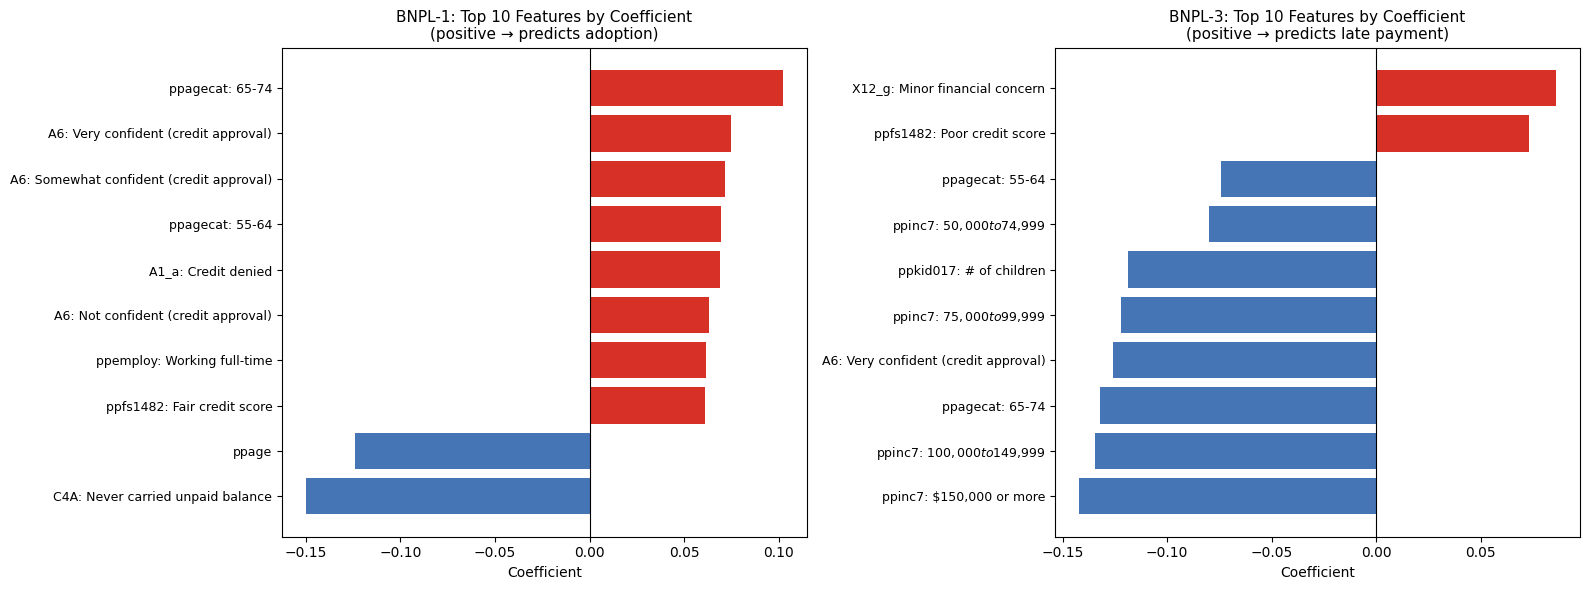

In [6]:

# Top 10 features by |coefficient| for BNPL-1 and BNPL-3
bnpl1_coefs = {
    'C4A: Never carried unpaid balance': -0.149976,
    'ppage': -0.124012,
    'ppagecat: 65-74': 0.102216,
    'A6: Very confident (credit approval)': 0.074809,
    'A6: Somewhat confident (credit approval)': 0.071688,
    'ppagecat: 55-64': 0.069371,
    'A1_a: Credit denied': 0.068896,
    'A6: Not confident (credit approval)': 0.063020,
    'ppemploy: Working full-time': 0.061416,
    'ppfs1482: Fair credit score': 0.061267,
}

bnpl3_coefs = {
    'ppinc7: $150,000 or more': -0.142180,
    'ppinc7: $100,000 to $149,999': -0.134585,
    'ppagecat: 65-74': -0.132270,
    'A6: Very confident (credit approval)': -0.126127,
    'ppinc7: $75,000 to $99,999': -0.122182,
    'ppkid017: # of children': -0.118877,
    'X12_g: Minor financial concern': 0.086143,
    'ppinc7: $50,000 to $74,999': -0.079987,
    'ppagecat: 55-64': -0.074460,
    'ppfs1482: Poor credit score': 0.073059,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(
    axes,
    [bnpl1_coefs, bnpl3_coefs],
    [
        'BNPL-1: Top 10 Features by Coefficient\n(positive → predicts adoption)',
        'BNPL-3: Top 10 Features by Coefficient\n(positive → predicts late payment)',
    ],
):
    coefs, features = zip(*sorted(zip(data.values(), data.keys())))
    colors = ['#d73027' if c > 0 else '#4575b4' for c in coefs]
    ax.barh(features, coefs, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()
